In [1]:
import sqlite3
import pandas as pd

# Connect to the SQLite database inside your folder
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

# Get list of all table names
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

print("Connected! Tables found in Chinook:")
print(tables)

# Export each table to a CSV file for examination
for table in tables['name']:
    df = pd.read_sql_query(f"SELECT * FROM {table}", conn)
    df.to_csv(f"{table}.csv", index=False)
    print(f"Exported: {table}.csv ({len(df)} rows)")

Connected! Tables found in Chinook:
             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track
Exported: Album.csv (347 rows)
Exported: Artist.csv (275 rows)
Exported: Customer.csv (59 rows)
Exported: Employee.csv (8 rows)
Exported: Genre.csv (25 rows)
Exported: Invoice.csv (412 rows)
Exported: InvoiceLine.csv (2240 rows)
Exported: MediaType.csv (5 rows)
Exported: Playlist.csv (18 rows)
Exported: PlaylistTrack.csv (8715 rows)
Exported: Track.csv (3503 rows)


In [3]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect("Chinook_Sqlite.sqlite")

# Query 1: Overall Revenue & Key Business Metrics
query_1 = """
SELECT 
    ROUND(SUM(Total), 2) AS Total_Revenue,
    COUNT(InvoiceId) AS Total_Invoices,
    ROUND(AVG(Total), 2) AS Average_Order_Value,
    COUNT(DISTINCT CustomerId) AS Total_Customers
FROM Invoice;
"""

# Run query and display results
df_metrics = pd.read_sql_query(query_1, conn)
df_metrics

,Total_Revenue,Total_Invoices,Average_Order_Value,Total_Customers
0,2328.6,412,5.65,59


In [4]:
# Query 2: Revenue by Music Genre
query_2 = """
SELECT 
    g.Name AS Genre_Name,
    SUM(il.Quantity) AS Units_Sold,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS Total_Revenue
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
JOIN Genre g ON t.GenreId = g.GenreId
GROUP BY g.GenreId
ORDER BY Total_Revenue DESC
LIMIT 10;
"""
df_genres = pd.read_sql_query(query_2, conn)
df_genres

,Genre_Name,Units_Sold,Total_Revenue
0,Rock,835,826.65
1,Latin,386,382.14
2,Metal,264,261.36
3,Alternative & Punk,244,241.56
4,TV Shows,47,93.53
5,Jazz,80,79.20
6,Blues,61,60.39
7,Drama,29,57.71
8,Classical,41,40.59
9,R&B/Soul,41,40.59


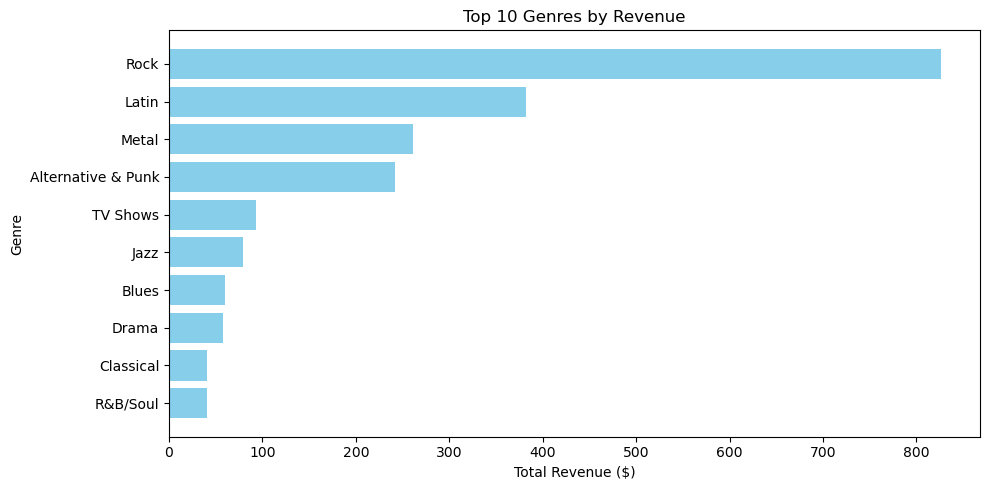

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(df_genres['Genre_Name'], df_genres['Total_Revenue'], color='skyblue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Genre')
plt.title('Top 10 Genres by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [6]:
# Query 3: Most Valuable Customers
query_3 = """
SELECT 
    c.CustomerId,
    c.FirstName || ' ' || c.LastName AS Customer_Name,
    c.Country,
    ROUND(SUM(i.Total), 2) AS Total_Spent,
    COUNT(i.InvoiceId) AS Total_Orders
FROM Customer c
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY c.CustomerId
ORDER BY Total_Spent DESC
LIMIT 10;
"""
df_customers = pd.read_sql_query(query_3, conn)
df_customers

,CustomerId,Customer_Name,Country,Total_Spent,Total_Orders
0,6,Helena Holý,Czech Republic,49.62,7
1,26,Richard Cunningham,USA,47.62,7
2,57,Luis Rojas,Chile,46.62,7
3,45,Ladislav Kovács,Hungary,45.62,7
4,46,Hugh O'Reilly,Ireland,45.62,7
5,24,Frank Ralston,USA,43.62,7
6,28,Julia Barnett,USA,43.62,7
7,37,Fynn Zimmermann,Germany,43.62,7
8,7,Astrid Gruber,Austria,42.62,7
9,25,Victor Stevens,USA,42.62,7


In [7]:
# Query 4: Sales Breakdown by Country
query_4 = """
SELECT 
    BillingCountry AS Country,
    COUNT(DISTINCT CustomerId) AS Customer_Count,
    COUNT(InvoiceId) AS Total_Invoices,
    ROUND(SUM(Total), 2) AS Total_Revenue,
    ROUND(AVG(Total), 2) AS Avg_Order_Value
FROM Invoice
GROUP BY BillingCountry
ORDER BY Total_Revenue DESC;
"""
df_country = pd.read_sql_query(query_4, conn)
df_country

,Country,Customer_Count,Total_Invoices,Total_Revenue,Avg_Order_Value
0,USA,13,91,523.06,5.75
1,Canada,8,56,303.96,5.43
2,France,5,35,195.10,5.57
3,Brazil,5,35,190.10,5.43
4,Germany,4,28,156.48,5.59
5,United Kingdom,3,21,112.86,5.37
6,Czech Republic,2,14,90.24,6.45
7,Portugal,2,14,77.24,5.52
8,India,2,13,75.26,5.79
9,Chile,1,7,46.62,6.66


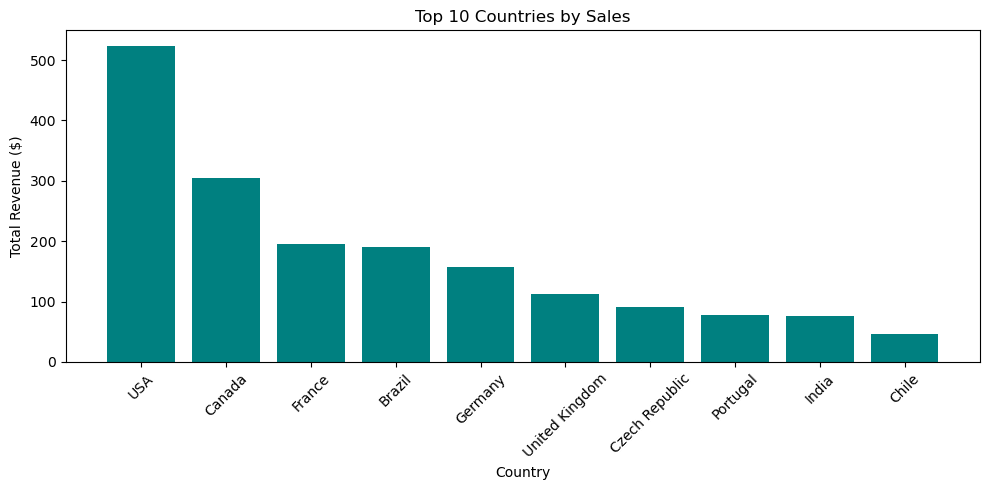

In [8]:
top_countries = df_country.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_countries['Country'], top_countries['Total_Revenue'], color='teal')
plt.xlabel('Country')
plt.ylabel('Total Revenue ($)')
plt.title('Top 10 Countries by Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# Query 5: Annual Revenue Growth
query_5 = """
SELECT 
    strftime('%Y', InvoiceDate) AS Sales_Year,
    COUNT(InvoiceId) AS Total_Orders,
    ROUND(SUM(Total), 2) AS Annual_Revenue
FROM Invoice
GROUP BY Sales_Year
ORDER BY Sales_Year ASC;
"""
df_yearly = pd.read_sql_query(query_5, conn)
df_yearly

,Sales_Year,Total_Orders,Annual_Revenue
0,2021,83,449.46
1,2022,83,481.45
2,2023,83,469.58
3,2024,83,477.53
4,2025,80,450.58


In [10]:
# Query 6: Revenue Generated by Artists
query_6 = """
SELECT 
    ar.Name AS Artist_Name,
    COUNT(DISTINCT il.InvoiceId) AS Orders_Count,
    SUM(il.Quantity) AS Tracks_Sold,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS Total_Revenue
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
JOIN Album al ON t.AlbumId = al.AlbumId
JOIN Artist ar ON al.ArtistId = ar.ArtistId
GROUP BY ar.ArtistId
ORDER BY Total_Revenue DESC
LIMIT 10;
"""
df_artists = pd.read_sql_query(query_6, conn)
df_artists

,Artist_Name,Orders_Count,Tracks_Sold,Total_Revenue
0,Iron Maiden,30,140,138.60
1,U2,32,107,105.93
2,Metallica,28,91,90.09
3,Led Zeppelin,28,87,86.13
4,Lost,12,41,81.59
5,The Office,10,25,49.75
6,Os Paralamas Do Sucesso,16,45,44.55
7,Deep Purple,10,44,43.56
8,Faith No More,11,42,41.58
9,Eric Clapton,17,40,39.60


In [11]:
# Query 7: Sales Performance by Employee
query_7 = """
SELECT 
    e.EmployeeId,
    e.FirstName || ' ' || e.LastName AS Sales_Rep,
    e.Title,
    COUNT(DISTINCT c.CustomerId) AS Assigned_Customers,
    COUNT(i.InvoiceId) AS Total_Sales_Made,
    ROUND(SUM(i.Total), 2) AS Total_Revenue_Generated
FROM Employee e
JOIN Customer c ON e.EmployeeId = c.SupportRepId
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY e.EmployeeId
ORDER BY Total_Revenue_Generated DESC;
"""
df_employees = pd.read_sql_query(query_7, conn)
df_employees

,EmployeeId,Sales_Rep,Title,Assigned_Customers,Total_Sales_Made,Total_Revenue_Generated
0,3,Jane Peacock,Sales Support Agent,21,146,833.04
1,4,Margaret Park,Sales Support Agent,20,140,775.40
2,5,Steve Johnson,Sales Support Agent,18,126,720.16


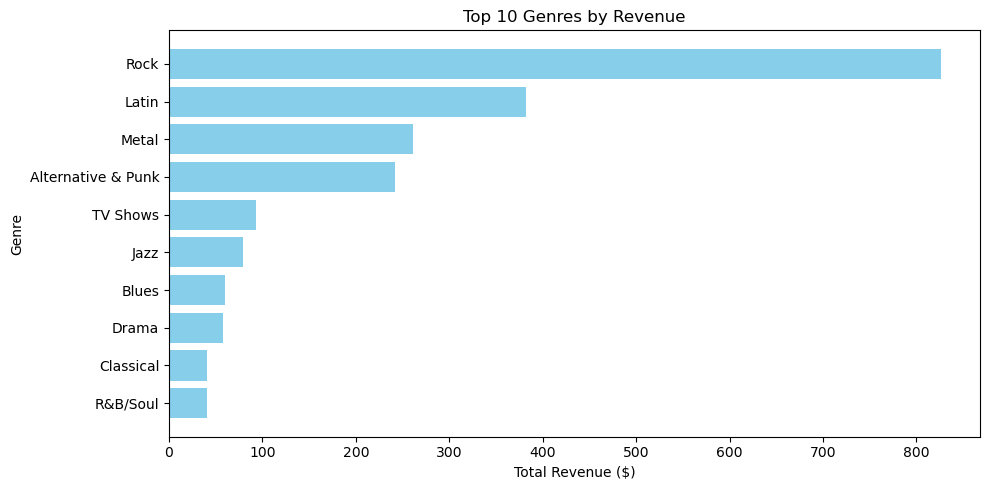

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(df_genres['Genre_Name'], df_genres['Total_Revenue'], color='skyblue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Genre')
plt.title('Top 10 Genres by Revenue')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


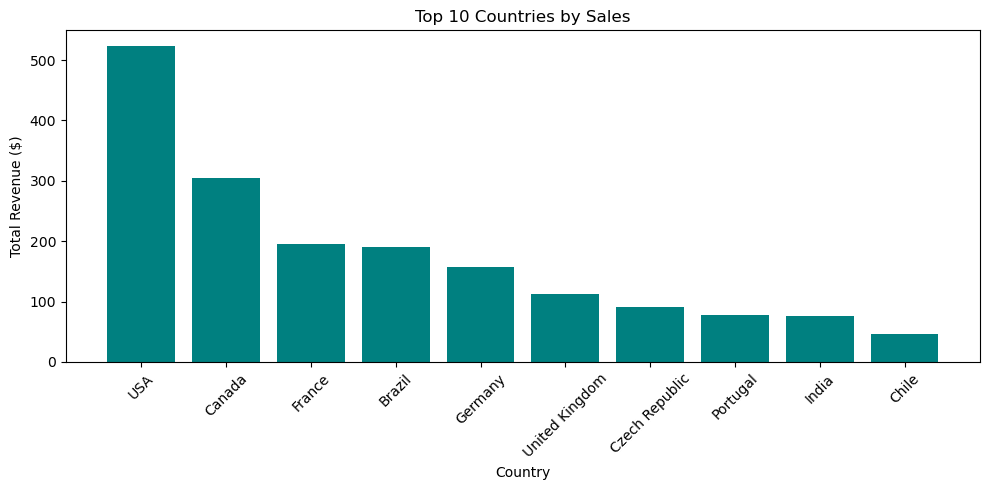

In [13]:
top_countries = df_country.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_countries['Country'], top_countries['Total_Revenue'], color='teal')
plt.xlabel('Country')
plt.ylabel('Total Revenue ($)')
plt.title('Top 10 Countries by Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

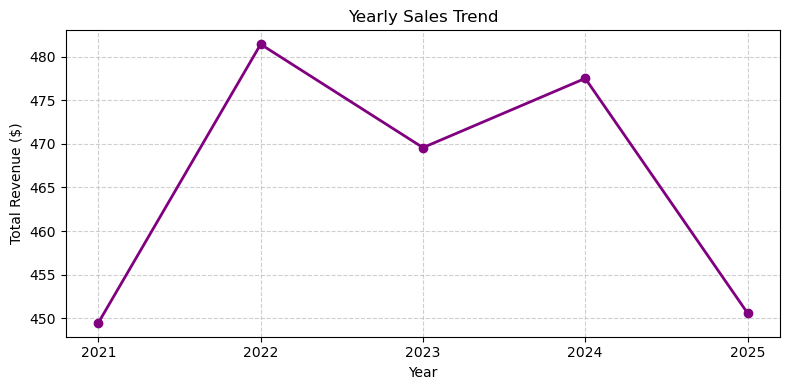

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(df_yearly['Sales_Year'], df_yearly['Annual_Revenue'], marker='o', color='purple', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Total Revenue ($)')
plt.title('Yearly Sales Trend')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

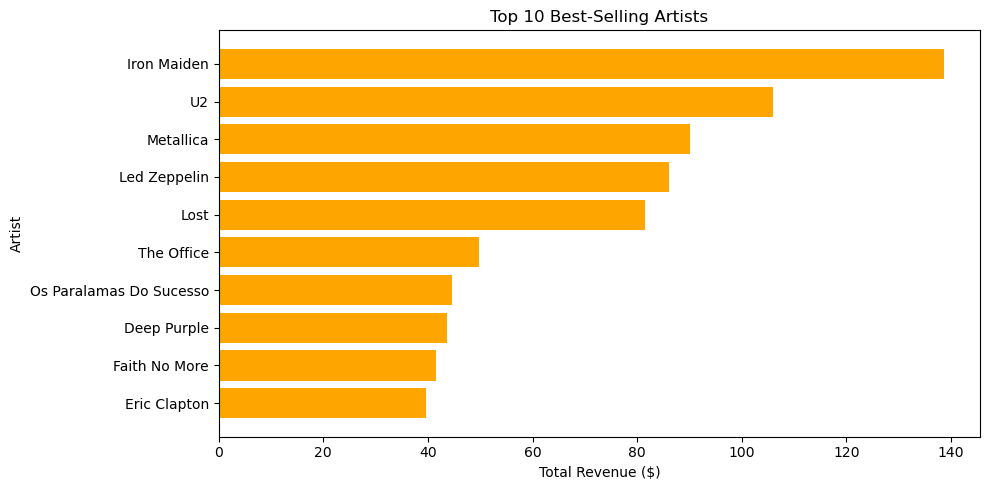

In [15]:
plt.figure(figsize=(10, 5))
plt.barh(df_artists['Artist_Name'], df_artists['Total_Revenue'], color='orange')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Artist')
plt.title('Top 10 Best-Selling Artists')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

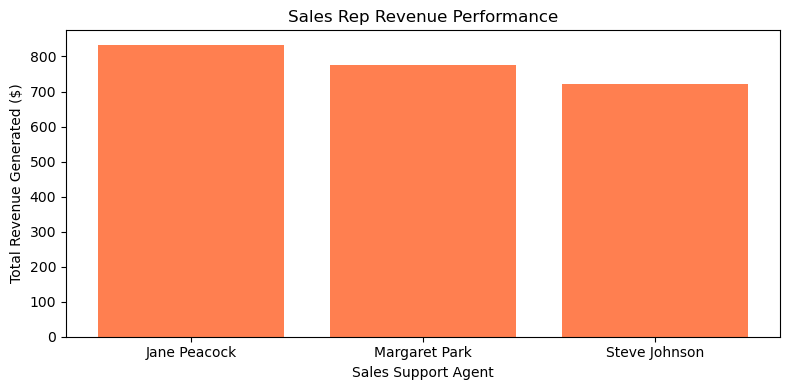

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(df_employees['Sales_Rep'], df_employees['Total_Revenue_Generated'], color='coral')
plt.xlabel('Sales Support Agent')
plt.ylabel('Total Revenue Generated ($)')
plt.title('Sales Rep Revenue Performance')
plt.tight_layout()
plt.show()

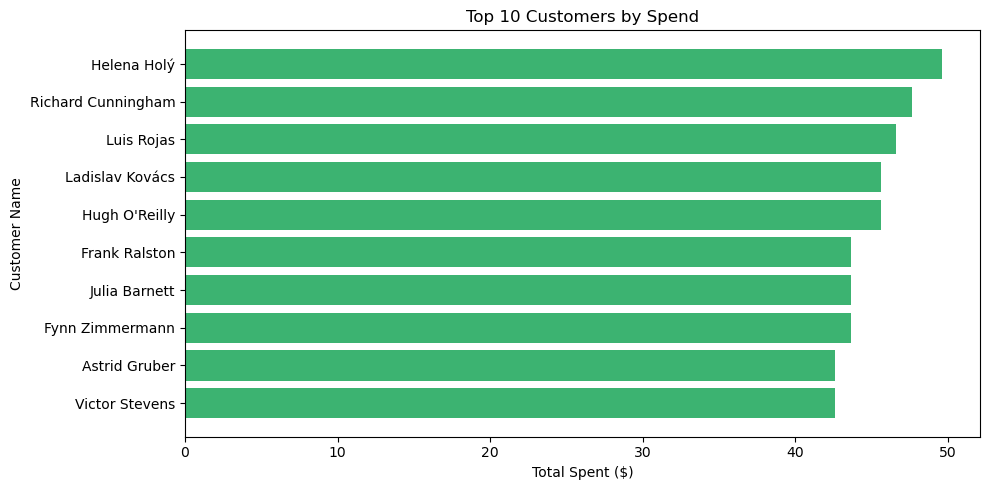

In [17]:
plt.figure(figsize=(10, 5))
plt.barh(df_customers['Customer_Name'], df_customers['Total_Spent'], color='mediumseagreen')
plt.xlabel('Total Spent ($)')
plt.ylabel('Customer Name')
plt.title('Top 10 Customers by Spend')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()